In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm 
from warnings import filterwarnings
filterwarnings ('ignore')



In [2]:
# professional color theme
plt.style.use ('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0,1,5))
primary_color= viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color= viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette= viridis_colors

In [3]:
df= pd.read_csv("C:\\Users\\kunal\\OneDrive\\Desktop\\portfolio website\\DataCoSupplyChainDataset.csv", encoding= 'latin-1')


In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [5]:
#overview of the data
print('rows, cols:',df.shape)
print('\columns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)
\columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [6]:
#data Cleaning
columns_to_drop= ['Product Description',
                  'Product Image',
                  'Customer Email',
                  'Customer Password',
                  'Customer Street',
                  'Customer Zipcode',
                  'Order Zipcode',
                  'Longitude',
                  'Latitude',
                  'Order Item Cardprod Id',
                  'Order Item Id',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Product Price',
                  'Order Item Quantity',
                  'Order Item Total',
                  'Category Id',
                  'Department Id',
                  'Order Id',
                  'Order Customer Id',
                  'Customer Id',
                  'Product Card Id',
                  'Product Category Id',
                  'Benefit per order',
                  'Product Status',
                  'Customer City',
                  'Order City',
                  'Order Country',
                  'Order State',
                  'Customer State',
                  'Market']


df= df.drop(columns=columns_to_drop)

In [8]:
#Standard date conversion
for c in ['order date (DateOrders)' , 'shipping date (DateOrders)']:
    df[c]=pd.to_datetime(df[c], errors='coerce',dayfirst=False)
          
#Check overview again
print('rows, cols:', df.shape)
print('\nmissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))


rows, cols: (180519, 22)

missing values (top 5):
Customer Lname                   8
Type                             0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [11]:
df= df.drop(columns='Customer Lname')

In [12]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Fname,Customer Segment,...,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Cally,Consumer,...,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Irene,Consumer,...,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Gillian,Consumer,...,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Tana,Home Office,...,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Orli,Corporate,...,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [13]:
for col in df.columns:
    if df[col].nunique()< 10:
        print(f'\n{col} values counts:')
        print(df[col].value_counts())


Type values counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) values counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled) values counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status values counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk values counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country values counts:
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment values counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status 

In [16]:
# Convert date columns first
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])


# Order processing time
df['Order processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days


# Delay calculation
df['Delay'] = (
    df['Order processing Time'] - df['Days for shipment (scheduled)']
)


# Delayed or not
df['Is_Delayed'] = df['Delay'] > 0


# Date features
df['order_month'] = df['order date (DateOrders)'].dt.month

df['order_day'] = df['order date (DateOrders)'].dt.day_name()

df['order_hour'] = df['order date (DateOrders)'].dt.hour


# summary
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order processing Time,Delay,order_month,order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,183.107609,0.548291,2016-06-12 17:47:04.669868,0.120647,203.772096,21.974989,141.232550,2016-06-16 05:45:23.202433,3.471856,0.540010,6.235449,11.483689
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 13:49:00,0.080000,119.980003,7.000000,50.000000,2015-09-25 06:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 13:06:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 08:32:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-03-01 08:42:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 21:29:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,120.043670,0.497664,NaN,0.466796,132.273077,104.433526,139.732492,NaN,1.670471,1.491881,3.403571,6.923006


In [17]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     98743
False    81776
Name: count, dtype: int64

In [18]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Fname',
       'Customer Segment', 'Department Name', 'order date (DateOrders)',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Region', 'Order Status', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Order processing Time',
       'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour'],
      dtype='str')

In [22]:
df['Order Profit Per Order'] > 0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 180519, dtype: bool

In [23]:
df['Profitability Flag']= np.where(df['Order Profit Per Order']>0, 'Profit', np.where(df['Order Profit Per Order']<0, 'loss', 'Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        145558
loss           33784
Break-even      1177
Name: count, dtype: int64

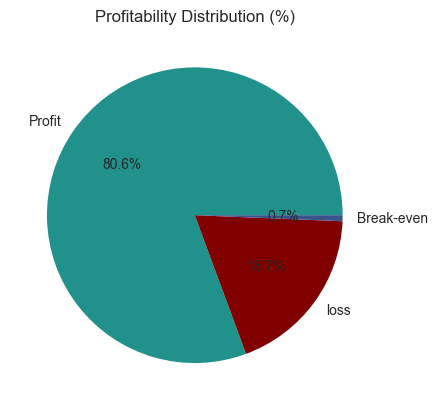

In [25]:
profit_counts= df['Profitability Flag'].value_counts(normalize=True)*100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

Key Performace Indicators

In [29]:
def format_fun(value):
    if value>=1e6:
        return f'{value/1e6:.1f}M $'
    elif value>=1e3:
        return f'{value/1e3:1f}K $'
    else:
        return f'{value:.0f} $'
    
delayed_df= df[df['Delay']>0]
metrics={}
metrics['Total Orders']=len(df)
metrics['Late Deliveries']=len(delayed_df)
metrics['90% Delay (days)']= delayed_df['Delay'].quantile(0.90)
metrics['On time delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100

metrics['Late Delivery %'] = float(metrics['Late Deliveries'] / metrics['Total Orders']) * 100

metrics['Total Profit'] = format_fun(
    df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
)

metrics['Total loss due to delays'] = format_fun(
    df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum()
)


print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k} : {v:.2f}")
    else:
        print(f"{k} : {v}")


--- Business KPIs ---

Total Orders : 180519
Late Deliveries : 98743
90% Delay (days) : 3.00
On time delivery % : 45.30
Late Delivery % : 54.70
Total Profit : 7.9M $
Total loss due to delays : 2.1M $


Profitability VS Delivery Time Analysis

In [31]:
profit_metrics= (
df.groupby('Delay')['Order Profit Per Order'].agg(
    mean_profit='mean',
    total_profit='sum',
    order_count='count'
)
.reset_index

)

In [32]:
profit_metrics

<bound method DataFrame.reset_index of        mean_profit  total_profit  order_count
Delay                                        
-2       23.423528  5.074942e+05        21666
-1       21.516997  4.669188e+05        21700
 0       22.044854  8.467429e+05        38410
 1       22.225592  1.244411e+06        55990
 2       21.246239  6.101495e+05        28718
 3       19.941130  1.406248e+05         7052
 4       21.561202  1.505619e+05         6983>

In [33]:
delay_distribution=(
    df['Delay']
    .value_counts(normalize=True)
    .sort_index()*100
).reset_index()

In [34]:
delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291



Profit Metrics by Delay Day:


,Delay,total_profit,mean_profit
0,-2,507494.2,23.4
1,-1,466918.8,21.5
2,0,846742.9,22.0
3,1,1244410.9,22.2
4,2,610149.5,21.2
5,3,140624.8,19.9
6,4,150561.9,21.6



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


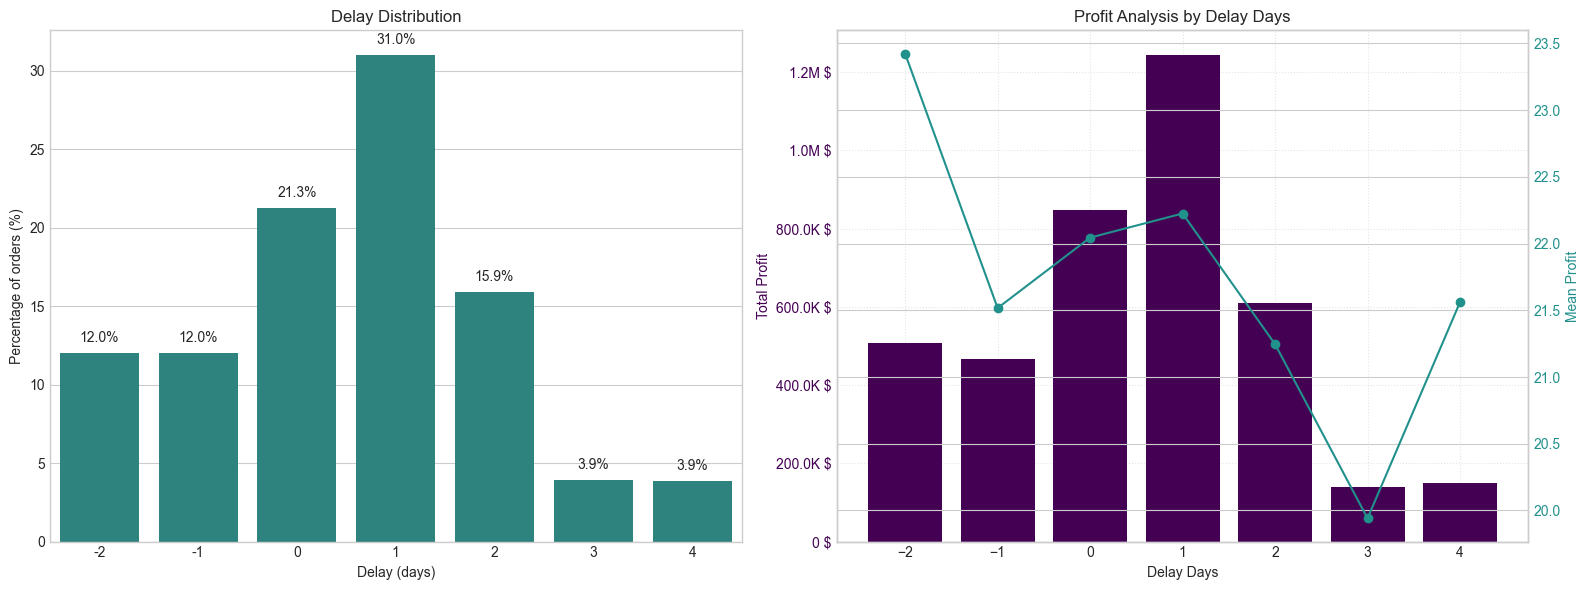

In [36]:
# Create profit metrics dataframe
profit_metrics = df.groupby('Delay').agg(
    total_profit=('Order Profit Per Order', 'sum'),
    mean_profit=('Order Profit Per Order', 'mean')
).reset_index()


# Rename delay distribution columns
delay_distribution.columns = ['Delay_Days', 'Percentage']


print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))


print("\nDelay Distribution (%):")
display(delay_distribution)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


# First subplot: Delay Distribution
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of orders (%)')


# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )


# Second subplot: Profit Analysis by Delay Days

ax2.set_xlabel("Delay Days")
ax2.set_ylabel("Total Profit", color=primary_color)

ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)

ax2.tick_params(
    axis='y',
    labelcolor=primary_color
)


# Create second y axis
ax3 = ax2.twinx()


ax3.set_ylabel(
    "Mean Profit",
    color=accent_color
)

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    label='Mean Profit',
    color=accent_color
)

ax3.tick_params(
    axis='y',
    labelcolor=accent_color
)


# Format total profit axis to K $, M $

def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(format_func)
)


ax2.set_title("Profit Analysis by Delay Days")


ax2.grid(
    True,
    linestyle=':',
    alpha=0.5
)


plt.tight_layout()
plt.show()

Bottleneck detection

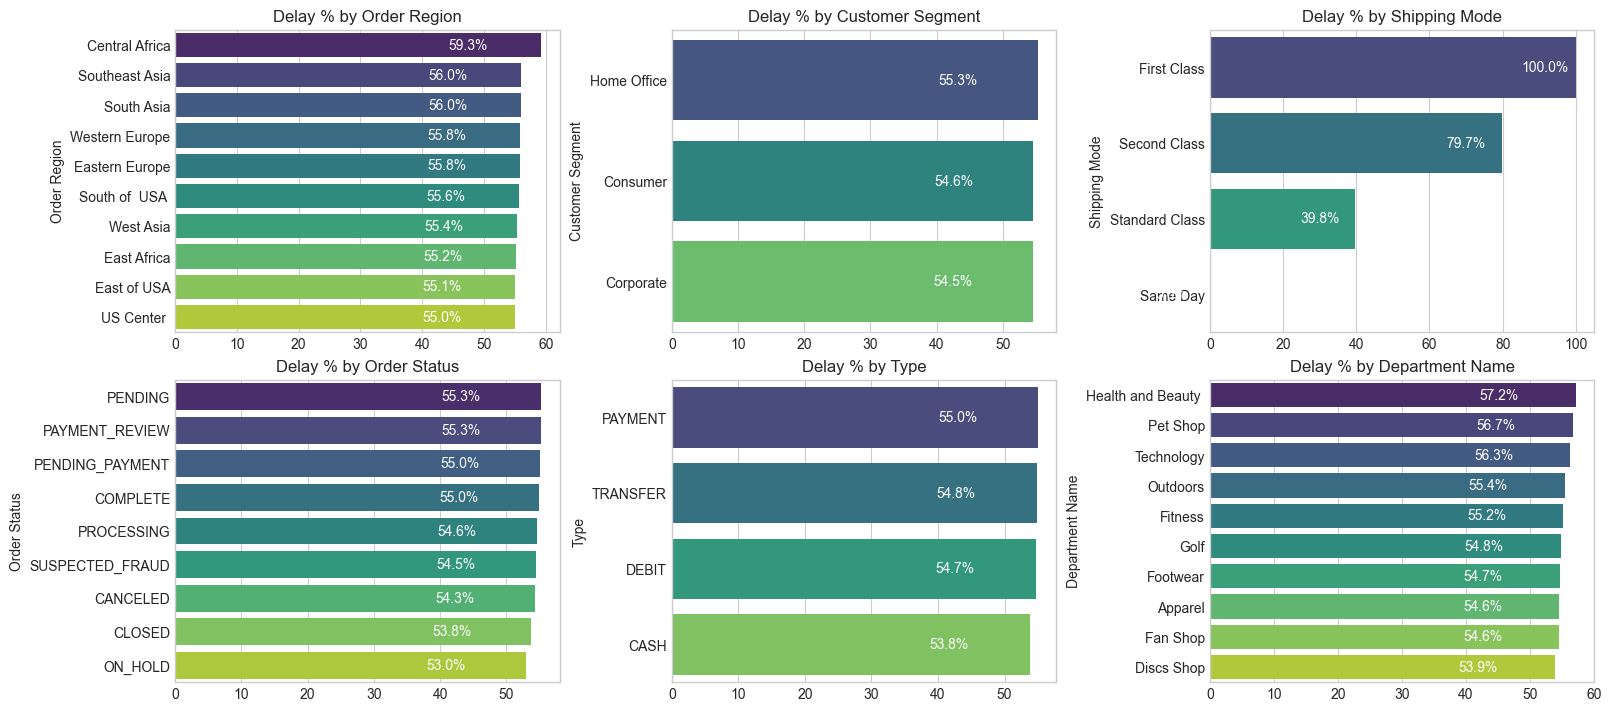

In [37]:
def compute_delay_pct_by_category(category):
    
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (
        cat_df['late_orders'] / cat_df['total_orders']
    ) * 100

    cat_df = cat_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    return cat_df



categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 7),
    constrained_layout=True
)

axes = axes.flatten()


for ax, category in zip(axes, categories):

    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )


plt.show()

Root Cause Analysis

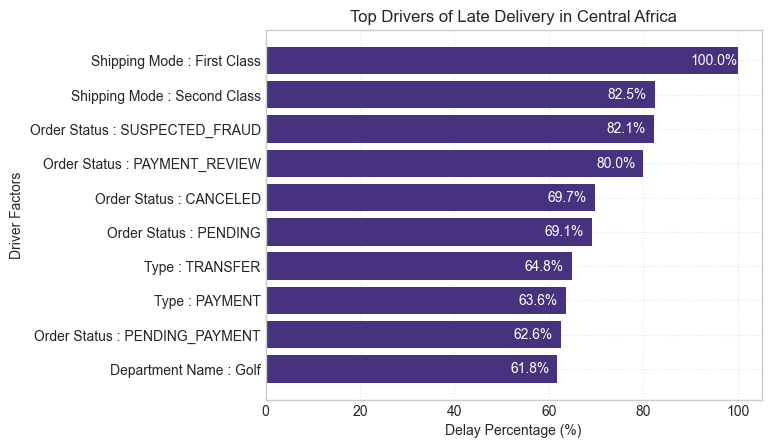

In [38]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()
    
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )
        
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])
        
    # Combine all drivers
    final_df = pd.concat(all_factors)
    
    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()
    
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                 f"{width:.1f}%",
                 va='center', fontsize = 10, color = 'white')
                 
    plt.show()

top_drivers_for_region('Central Africa')

Time-Based Analysis

In [39]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [41]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.541743,54.174314
1,2,0.545736,54.573611
2,3,0.549029,54.902946
3,4,0.544542,54.454163
4,5,0.550388,55.038808
5,6,0.545016,54.501618
6,7,0.541201,54.120085
7,8,0.552916,55.291604
8,9,0.552327,55.232746
9,10,0.541953,54.195291


In [42]:
delay_by_hour


,order_hour,Is_Delayed,delay_pct
0,0,0.539921,53.992095
1,1,0.553380,55.338008
2,2,0.553472,55.347241
3,3,0.539919,53.991935
4,4,0.538800,53.880036
5,5,0.552628,55.262811
6,6,0.523796,52.379642
7,7,0.551210,55.121043
8,8,0.530195,53.019502
9,9,0.544304,54.430380


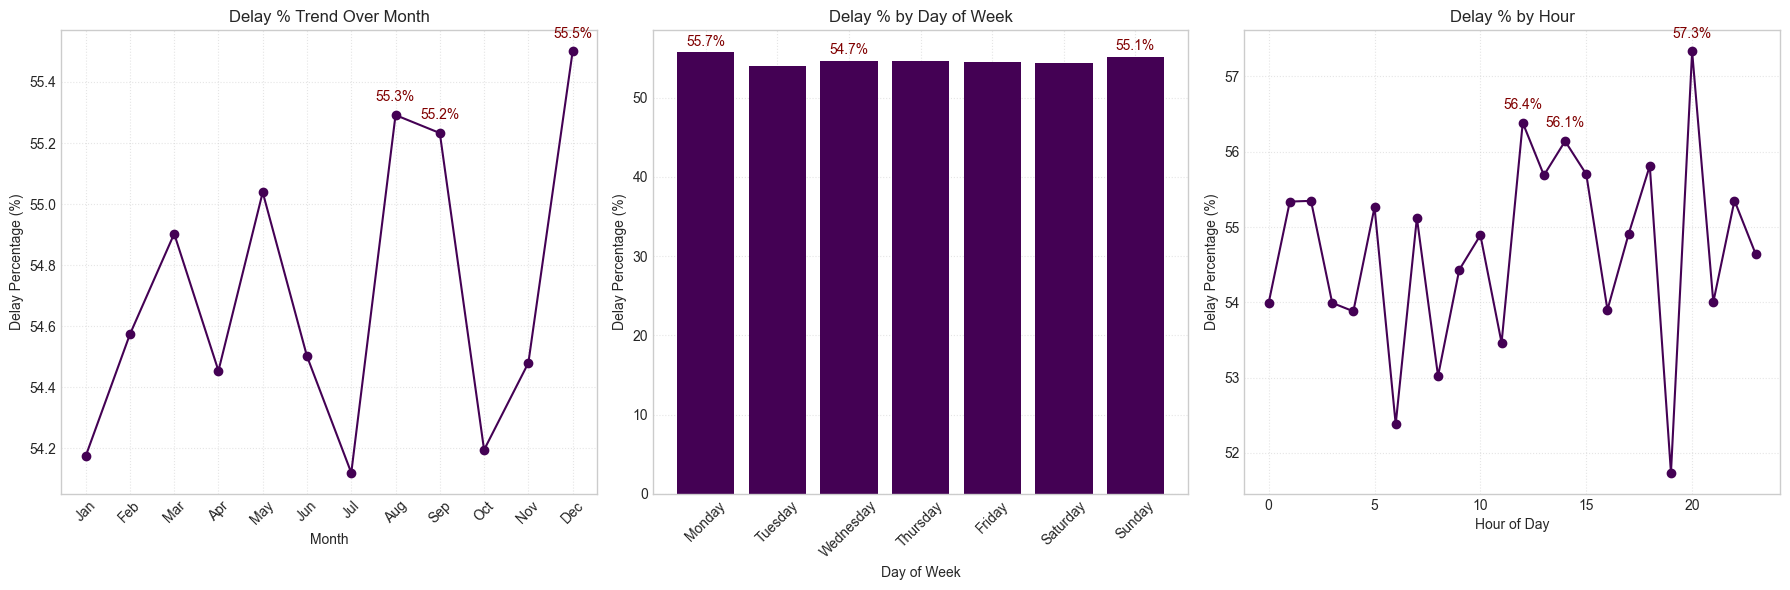

In [43]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f"{height:.1f}%", ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

In [50]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import sklearn
print(sklearn.__version__)

1.8.0


In [53]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [55]:
X = df[['Type','Days for shipment (scheduled)','Category Name',
        'Customer Segment','Department Name','Order Region',
        'Shipping Mode','order_month','order_hour']]
y = df['Late_delivery_risk']

In [56]:
# Find categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('categorical columns:', cat_cols)


# Frequency Encoding
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)


# Drop original categorical columns
X_encoded = X.drop(columns=cat_cols)

print('Shape after frequency encoding:', X_encoded.shape)


# Final features
X = X_encoded


# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after frequency encoding: (180519, 9)


In [57]:
y.value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [58]:
# Balancing the training data using SMOTE

print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79181, 0: 65234})
After balancing (train): Counter({1: 79181, 0: 79181})


In [59]:
def evaluate_model(y_true, y_pred, model_name):

    print(f"\n--- {model_name} ---")

    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))

    print("Precision:", round(precision_score(y_true, y_pred), 2))

    print("Recall:", round(recall_score(y_true, y_pred), 2))

    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [60]:
# Fit the Random Forest model on balanced data

rf_model_balanced = RandomForestClassifier(
    random_state=42
)

rf_model_balanced.fit(
    X_train_bal,
    y_train_bal
)


# Prediction on unseen test data

y_pred_rf_balanced = rf_model_balanced.predict(
    X_test
)


# Evaluate performance

evaluate_model(
    y_test,
    y_pred_rf_balanced,
    "Random Forest Classifier"
)


--- Random Forest Classifier ---
Accuracy: 0.73
Precision: 0.77
Recall: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.71     16308
           1       0.77      0.74      0.75     19796

    accuracy                           0.73     36104
   macro avg       0.73      0.73      0.73     36104
weighted avg       0.74      0.73      0.73     36104

